# cw_odmr_lock_in results

Lock-in (SR830) X/Y readout vs. microwave frequency for each run in `D:\cw_odmr_lock_in` (see `cw_odmr_lock_in.py`). Add a new run by appending its name to `RUN_NAMES` below and rerunning from there -- no more hand-editing individual cells per run.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = r"D:\cw_odmr_lock_in"
RUN_NAMES = ["lockin1", "lockin2", "lockin3", "lockin5", "lockin6",
             "lockin7", "lockin8", "lockin9"]

runs = {}
for name in RUN_NAMES:
    run_path = f"{DATA_DIR}/{name}"
    freqs_hz = np.load(f"{run_path}/{name}_lockin_spectrum_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_lockin_spectrum_x.npy")
    y = np.load(f"{run_path}/{name}_lockin_spectrum_y.npy")
    reflected_dbm = np.load(f"{run_path}/{name}_lockin_spectrum_reflected_dbm.npy")
    with open(f"{run_path}/{name}_lockin_spectrum_metadata.txt") as fh:
        metadata = fh.read()
    freqs_ghz = freqs_hz / 1e9
    runs[name] = dict(freqs_ghz=freqs_ghz, x=x, y=y, r=np.hypot(x, y),
                       reflected_dbm=reflected_dbm, metadata=metadata)
    print(f"{name}: {len(freqs_hz)} points, "
          f"{freqs_ghz.min():.6f}-{freqs_ghz.max():.6f} GHz")

lockin1: 24 points, 2.895625-2.907125 GHz
lockin2: 1196 points, 2.876525-2.888475 GHz
lockin3: 140 points, 2.853525-2.867425 GHz
lockin5: 128 points, 2.852425-2.865125 GHz
lockin6: 122 points, 2.866700-2.878800 GHz
lockin7: 236 points, 2.866675-2.878425 GHz
lockin8: 116 points, 2.866900-2.878400 GHz
lockin9: 118 points, 2.866725-2.878425 GHz


## Individual spectra

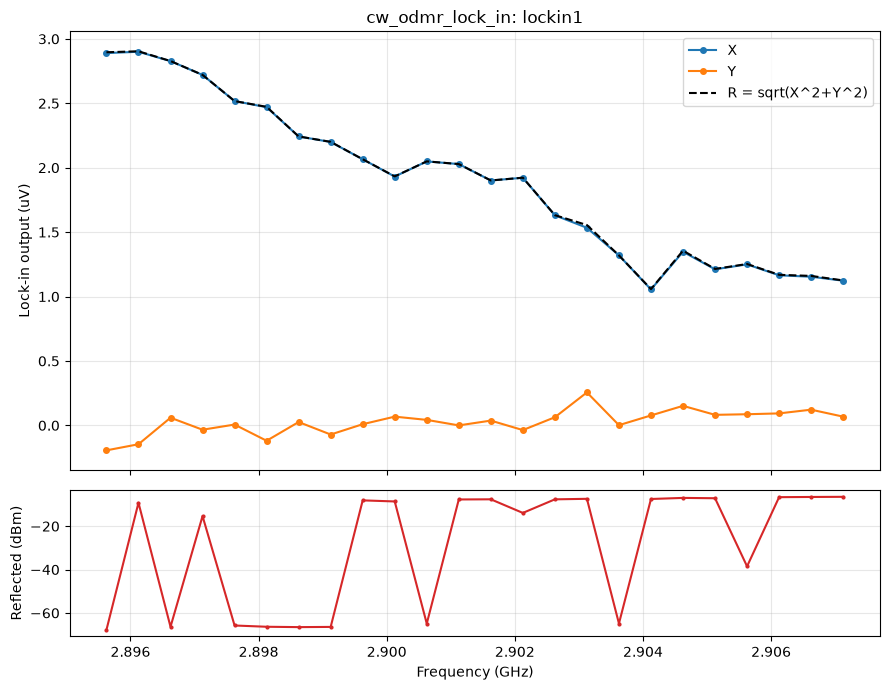

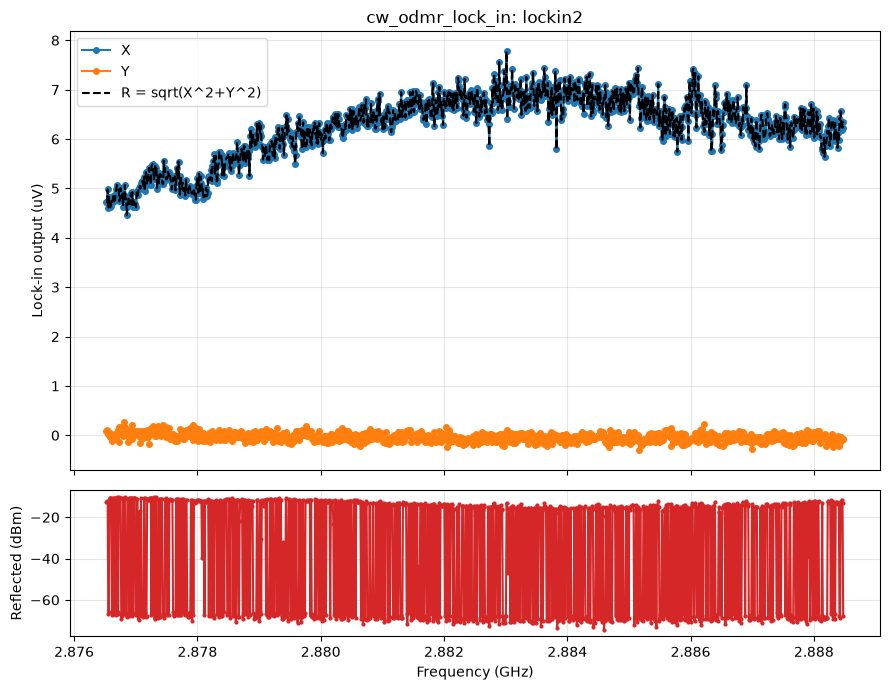

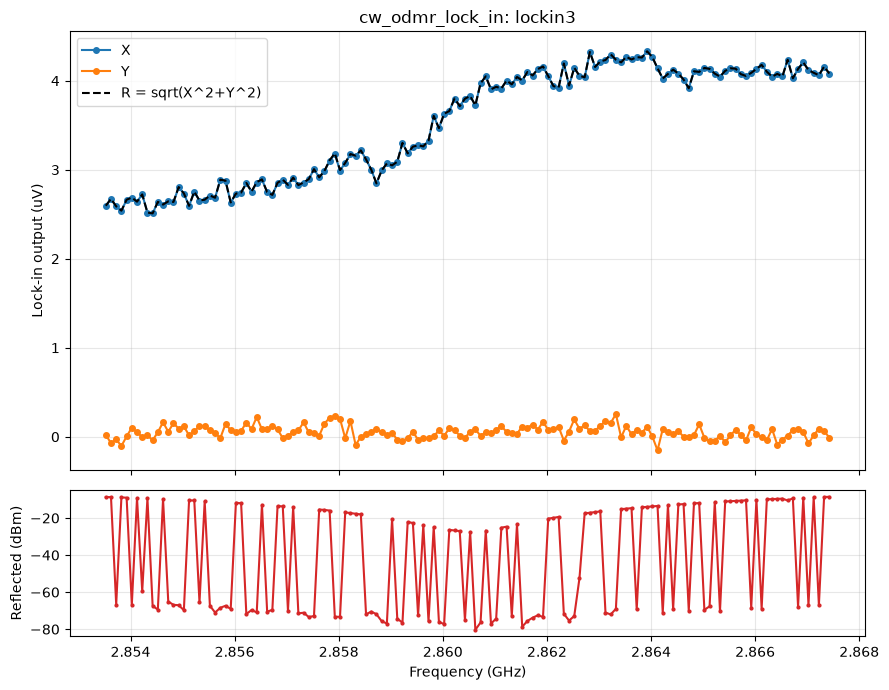

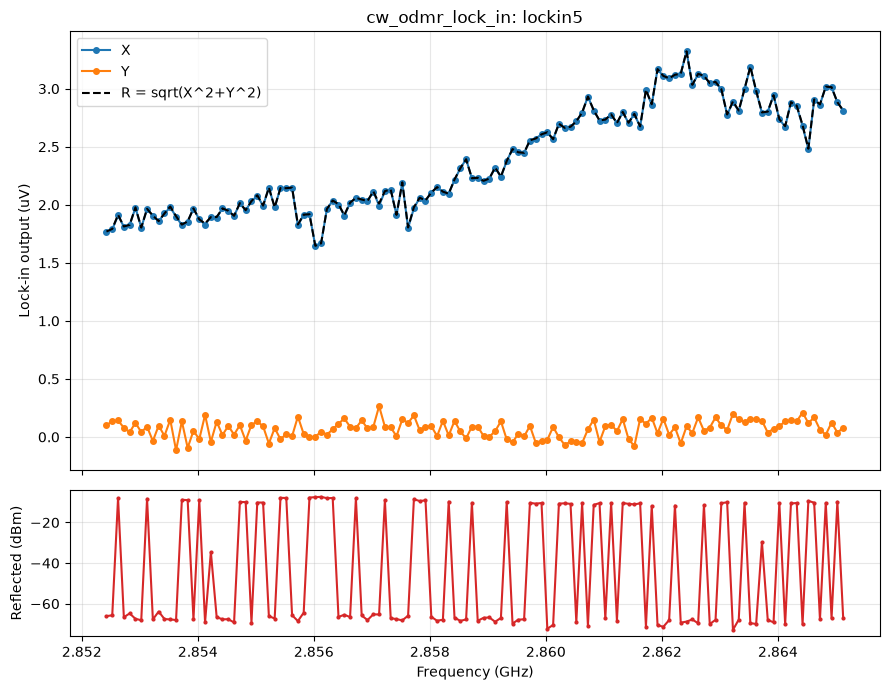

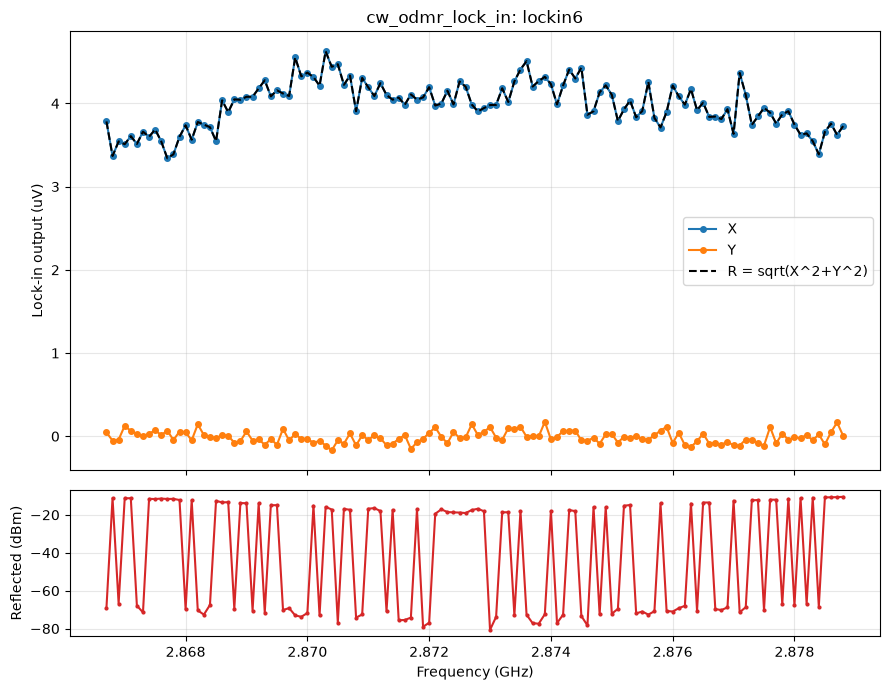

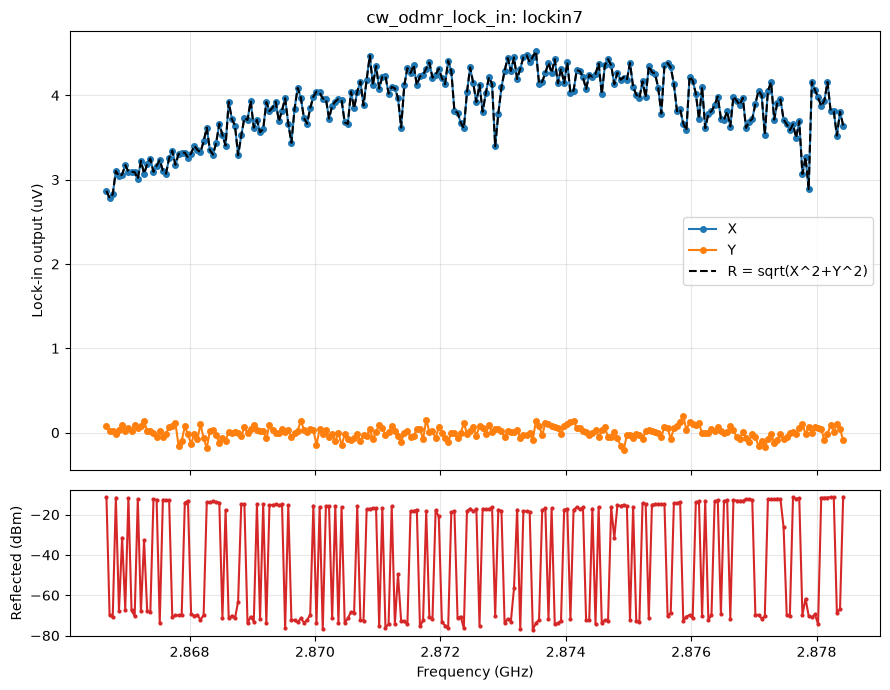

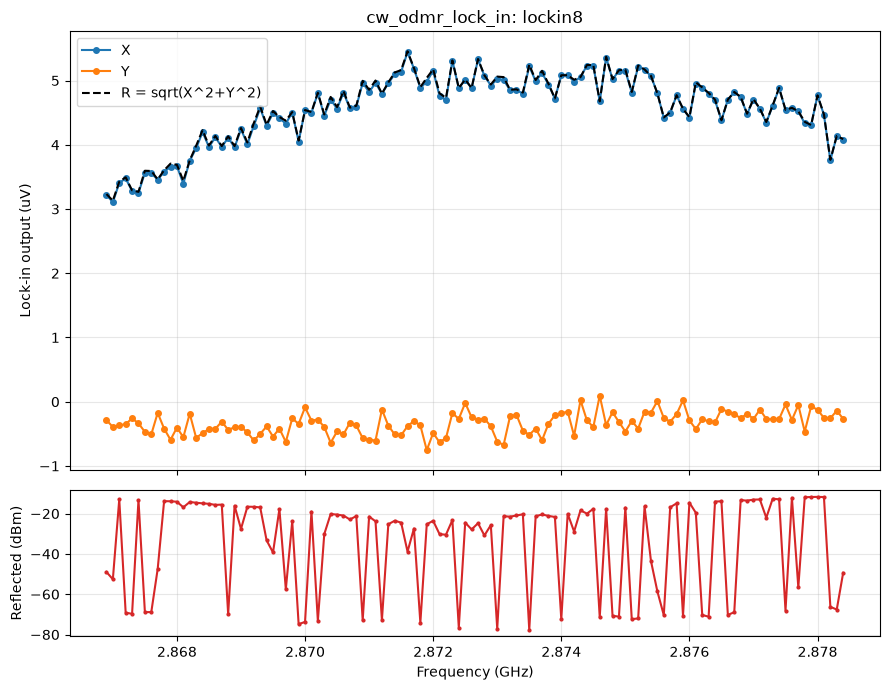

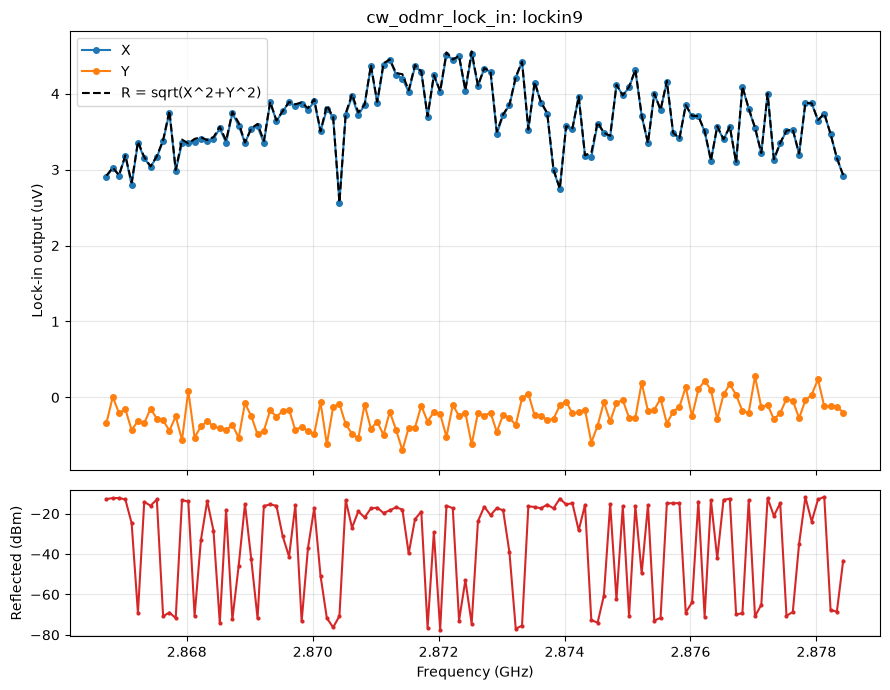

In [3]:
for name in RUN_NAMES:
    d = runs[name]
    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})

    ax = axes[0]
    ax.plot(d["freqs_ghz"], d["x"] * 1e6, "o-", label="X", ms=4)
    ax.plot(d["freqs_ghz"], d["y"] * 1e6, "o-", label="Y", ms=4)
    ax.plot(d["freqs_ghz"], d["r"] * 1e6, "k--", label="R = sqrt(X^2+Y^2)", lw=1.5)
    ax.set_ylabel("Lock-in output (uV)")
    ax.set_title(f"cw_odmr_lock_in: {name}")
    ax.legend()
    ax.grid(alpha=0.3)

    axes[1].plot(d["freqs_ghz"], d["reflected_dbm"], ".-", color="tab:red", ms=4)
    axes[1].set_ylabel("Reflected (dBm)")
    axes[1].set_xlabel("Frequency (GHz)")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Comparison plot

Edit `COMPARISON_RUN_NAMES` to change which runs get overlaid -- excludes lockin1 by default (matches how this comparison was built up run-by-run originally).

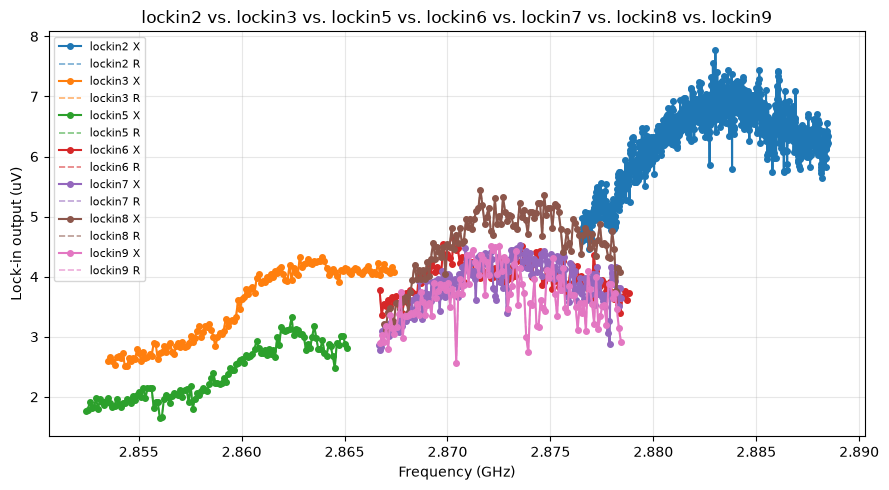

In [4]:
COMPARISON_RUN_NAMES = [n for n in RUN_NAMES if n != "lockin1"]
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(9, 5))
for i, name in enumerate(COMPARISON_RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    ax.plot(d["freqs_ghz"], d["x"] * 1e6, "o-", color=color, ms=4, label=f"{name} X")
    ax.plot(d["freqs_ghz"], d["r"] * 1e6, "--", color=color, lw=1.2, alpha=0.6, label=f"{name} R")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in output (uV)")
ax.set_title(" vs. ".join(COMPARISON_RUN_NAMES))
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# lockin4: coarse resonance sweep

From `D:\cw_odmr_lock_in\lockin4\lockin4_resonance_coarse.csv` (the wide sweep `resonance_sweep()` uses to locate the approximate dip before the fine sweep).

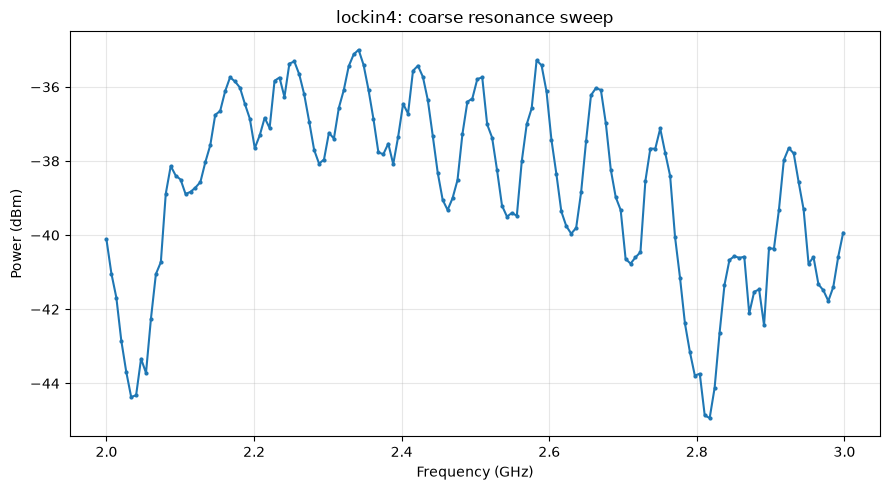

In [4]:
coarse4 = np.genfromtxt(
    r"D:\cw_odmr_lock_in\lockin4\lockin4_resonance_coarse.csv",
    delimiter=",", skip_header=1,
)
coarse4_freq_ghz = coarse4[:, 0] / 1e9
coarse4_power_dbm = coarse4[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(coarse4_freq_ghz, coarse4_power_dbm, ".-", ms=4)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Power (dBm)")
ax.set_title("lockin4: coarse resonance sweep")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# lockin5: coarse resonance sweep, OSL-calibrated vs. raw

Applying the open-short-load calibration saved at `D:\cw_odmr_lock_in\osl_cal` (see `hp8673h.py`'s `calibrate_osl()`/`apply_osl_calibration()`) to `lockin5`'s coarse resonance sweep, and comparing before/after. Recall this is a scalar calibration -- it corrects the cable/coupler's frequency-dependent loss (dip depth/baseline shape), not source-match/directivity error, and doesn't move the dip frequency.

In [5]:
import sys
sys.path.insert(0, r"C:\Users\codin\Documents\projects\diamonds\experiment")
from hp8673h import HP8673H

cal = HP8673H.load_osl_calibration(r"D:\cw_odmr_lock_in\osl_cal")

coarse5_raw = np.genfromtxt(
    r"D:\cw_odmr_lock_in\lockin5\lockin5_resonance_coarse.csv",
    delimiter=",", skip_header=1,
)
coarse5_freqs_hz = coarse5_raw[:, 0]
coarse5_power_dbm_raw = coarse5_raw[:, 1]
coarse5_power_dbm_cal = HP8673H.apply_osl_calibration(
    coarse5_freqs_hz, coarse5_power_dbm_raw, cal,
)
coarse5_freq_ghz = coarse5_freqs_hz / 1e9

print(f"{len(coarse5_freqs_hz)} points, {coarse5_freq_ghz.min():.4f}-{coarse5_freq_ghz.max():.4f} GHz")

150 points, 2.0000-2.9983 GHz


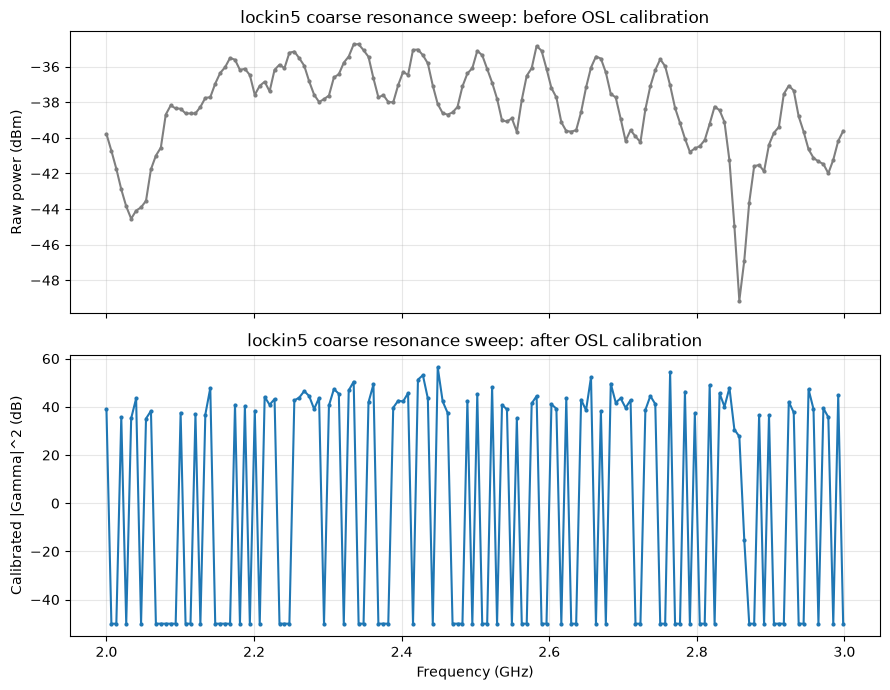

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(coarse5_freq_ghz, coarse5_power_dbm_raw, ".-", ms=4, color="tab:gray")
axes[0].set_ylabel("Raw power (dBm)")
axes[0].set_title("lockin5 coarse resonance sweep: before OSL calibration")
axes[0].grid(alpha=0.3)

axes[1].plot(coarse5_freq_ghz, coarse5_power_dbm_cal, ".-", ms=4, color="tab:blue")
axes[1].set_ylabel("Calibrated |Gamma|^2 (dB)")
axes[1].set_xlabel("Frequency (GHz)")
axes[1].set_title("lockin5 coarse resonance sweep: after OSL calibration")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Overlay (normalized to each curve's own baseline, for direct shape comparison)

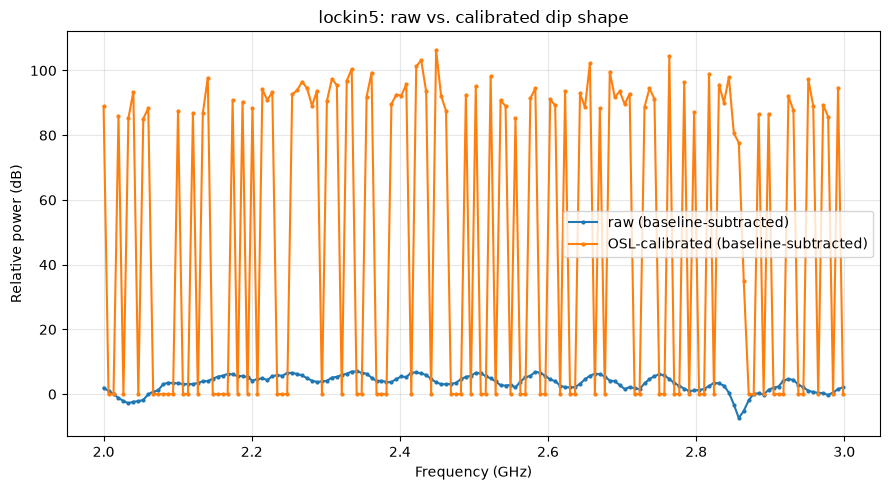

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

raw_norm = coarse5_power_dbm_raw - np.median(coarse5_power_dbm_raw[:5])
cal_norm = coarse5_power_dbm_cal - np.median(coarse5_power_dbm_cal[:5])

ax.plot(coarse5_freq_ghz, raw_norm, ".-", ms=4, label="raw (baseline-subtracted)")
ax.plot(coarse5_freq_ghz, cal_norm, ".-", ms=4, label="OSL-calibrated (baseline-subtracted)")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Relative power (dB)")
ax.set_title("lockin5: raw vs. calibrated dip shape")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()